<a href="https://colab.research.google.com/github/swayambel/Yarkovsky-induced-integrator-analysis/blob/main/yarkovsky_stability_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Impact of Yarkovsky Effect on Orbital Stability under Different Numerical Integrators

---

**Author:** Swayam Beluse  
**Subject:** Computational Physics — Orbital Dynamics & Numerical Methods  

---

> *"The Yarkovsky effect is one of the most subtle yet consequential non-gravitational forces in solar system dynamics — a thermal whisper that reshapes asteroid orbits over millennia. This study examines how different numerical integration schemes interact with such small perturbations, and when numerical error drowns out the physical signal."*

---

## 1. Project Overview

This notebook presents a structured computational study of how the **Yarkovsky effect**, a subtle radiation-pressure-induced thermal force influences the orbital evolution of a small body in a two-body gravitational system. We investigate this under three numerical integrators of varying order and symplecticity.

### Motivation

In planetary defense and long-term asteroid tracking, both **physical perturbations** (e.g., Yarkovsky drift) and **numerical errors** accumulate over time. A naive simulation might misattribute numerical drift as a real physical effect — or worse, let numerical noise completely mask a real signal. Understanding this interplay is central to reliable long-term orbital predictions.

### Scope

- Simulate a 2D two-body orbit with and without the Yarkovsky perturbation
- Compare three integrators: **Euler**, **RK4**, and **Velocity Verlet**
- Quantify numerical vs. physical drift through energy analysis
- Assess timestep sensitivity and stability
- Draw physically meaningful conclusions about integrator suitability

---

## 2. Project Objectives

The objectives of this study are:

1. Implement a normalized **two-body gravitational model** with ($GM = 1$).

2. Model the Yarkovsky effect as a small **tangential acceleration** acting along the velocity direction.

3. Implement and compare numerical integrators: **Euler** (baseline), **RK4** (high-order), and **Velocity Verlet** (symplectic).

4. Analyze **orbital trajectories** and **energy conservation** over long timescales.

5. Distinguish **numerical drift** from **physical** (Yarkovsky-induced) **drift**.

6. Perform **timestep sensitivity analysis** to evaluate accuracy and stability.

7. Determine the most suitable integrator for **long-term orbital stability under perturbations**.

---


## 3. Physical Model

### 3.1 Gravitational Two-Body System

We model a small body (e.g., asteroid) orbiting a central mass under Newtonian gravity. The system is normalized so that:

$$GM = 1, \quad r_0 = 1 \text{ AU (normalized)}, \quad T_0 = 2\pi \text{ (one orbit)}$$

The gravitational equation of motion is:

$$\frac{d^2 \mathbf{r}}{dt^2} = -\frac{GM\, \mathbf{r}}{|\mathbf{r}|^3}$$

### 3.2 The Yarkovsky Effect

The **Yarkovsky effect** arises from anisotropic thermal radiation from a rotating body. A sunlit asteroid absorbs solar radiation and re-emits it as thermal photons preferentially in a direction offset from the Sun–asteroid line due to thermal inertia. This produces a net non-gravitational force approximately tangential to the orbit.

In the diurnal Yarkovsky variant, this force acts along the velocity vector for a prograde rotator (leading to orbital expansion) or against it for a retrograde rotator (leading to contraction). We model it as a **tangential acceleration approximately aligned with the velocity vector**:

$$\mathbf{a}_{\text{Yark}} = A \cdot \hat{\mathbf{v}} = A \cdot \frac{\mathbf{v}}{|\mathbf{v}|}$$

where $A$ is a small scalar amplitude ($ 10^{-6}$ to $10^{-4}$ in normalized units).

### 3.3 Total Acceleration

$$\mathbf{a}_{\text{total}} = \mathbf{a}_{\text{grav}} + \mathbf{a}_{\text{Yark}} = -\frac{\mathbf{r}}{|\mathbf{r}|^3} + A \cdot \frac{\mathbf{v}}{|\mathbf{v}|}$$

### 3.4 Specific Orbital Energy

For a purely gravitational orbit, the specific mechanical energy is conserved:

$$E = \frac{1}{2}|\mathbf{v}|^2 - \frac{GM}{|\mathbf{r}|} = \frac{1}{2}v^2 - \frac{1}{r}$$

Deviations in $|E(t) - E_0|$ provide a direct measure of numerical error in the pure gravity case, and reflect the combined effect of **numerical error** and **physical (Yarkovsky-induced) drift** when perturbations are included.

---

## 4. Equations of Motion

Writing the system as a first-order ODE in phase space $\mathbf{y} = (x, y, v_x, v_y)$:

$$\frac{d}{dt}\begin{pmatrix} x \\ y \\ v_x \\ v_y \end{pmatrix} = \begin{pmatrix} v_x \\ v_y \\ a_x \\ a_y \end{pmatrix}$$

where:

$$a_x = -\frac{x}{(x^2+y^2)^{3/2}} + A \frac{v_x}{\sqrt{v_x^2+v_y^2}}$$

$$a_y = -\frac{y}{(x^2+y^2)^{3/2}} + A \frac{v_y}{\sqrt{v_x^2+v_y^2}}$$

The inclusion of the Yarkovsky term breaks the Hamiltonian structure of the system, rendering it **non-conservative**. As a result, the total mechanical energy is no longer conserved, and its evolution reflects a combination of **physical drift** (due to the perturbation) and **numerical error** (introduced by the integration scheme).

Distinguishing between these two contributions is central to the analysis carried out in this study.

---

## 5. Setup and Initial Conditions

This section defines the normalized physical parameters, initial conditions, and simulation timescales used throughout the study. Two simulation regimes are considered: a short-duration run for integrator comparison and a long-duration run to capture cumulative Yarkovsky-induced drift.

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import LogLocator
import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-darkgrid")
COLORS = {
    'euler':  '#e74c3c',
    'rk4':    '#2ecc71',
    'verlet': '#3498db',
    'ref':    '#95a5a6'
}

# --- Physical Parameters ---
GM        = 1.0          # Normalized gravitational parameter
A_YARK = 1e-8            # chosen so physical drift is comparable to numerical error

# --- Initial Conditions (slightly elliptical orbit) ---
X0  = 1.0
Y0  = 0.0
VX0 = 0.0
VY0 = 1.1                 # Slightly above circular velocity → bound elliptical orbit

STATE0 = np.array([X0, Y0, VX0, VY0])

# --- Simulation Parameters ---
DT          = 0.01
T_END_SHORT = 20 * np.pi  # ~10 orbits
T_END_LONG  = 20000 * np.pi # ~10000 orbits

print("=" * 55)
print("  Simulation Setup Summary")
print("=" * 55)
print(f"  GM (normalized)        : {GM}")
print(f"  Yarkovsky amplitude A  : {A_YARK:.1e}")
print(f"  Initial position (x,y) : ({X0}, {Y0})")
print(f"  Initial velocity (vx,vy): ({VX0}, {VY0})")
print(f"  Timestep dt            : {DT}")
print(f"  Short sim duration     : {T_END_SHORT:.2f} (~10 orbits)")
print(f"  Long sim duration      : {T_END_LONG:.2f} (~10000 orbits)")
r0 = np.sqrt(X0**2 + Y0**2)
v0 = np.sqrt(VX0**2 + VY0**2)
E0 = 0.5 * v0**2 - GM / r0
print(f"  Initial energy E0      : {E0:.6f}")
print("=" * 55)

  Simulation Setup Summary
  GM (normalized)        : 1.0
  Yarkovsky amplitude A  : 1.0e-08
  Initial position (x,y) : (1.0, 0.0)
  Initial velocity (vx,vy): (0.0, 1.1)
  Timestep dt            : 0.01
  Short sim duration     : 62.83 (~10 orbits)
  Long sim duration      : 62831.85 (~10000 orbits)
  Initial energy E0      : -0.395000


### Note on Initial Conditions

With $v_y = 1.1 > v_{\text{circ}} = \sqrt{GM/r} = 1.0$, the orbit has a slightly higher specific energy than the circular case, resulting in a mildly elliptical trajectory. This choice is deliberate: a perfectly circular orbit makes drift harder to visualize, while a highly eccentric orbit introduces strong periapsis dynamics that complicate interpretation.

The chosen initial condition provides a controlled regime in which long-term orbital drift due to the Yarkovsky effect can be observed clearly without being dominated by geometric extremes.

### 6. Yarkovsky Effect Modeling

The following functions define the physical model used throughout the simulations. Gravitational acceleration provides the baseline dynamics, while a simplified Yarkovsky term introduces a small tangential perturbation aligned with the velocity vector.

The modular structure allows controlled comparison between purely gravitational motion and perturbed dynamics, enabling clear separation of **numerical drift** and **physical (Yarkovsky-induced) drift**.

In [65]:
# --- Core Physics Functions ---

def gravity(r_vec):
    r_mag = np.linalg.norm(r_vec)
    return -GM * r_vec / r_mag**3


def yarkovsky(v_vec):
    v_mag = np.linalg.norm(v_vec)
    if v_mag < 1e-12:
        return np.zeros_like(v_vec)
    return A_YARK * v_vec / v_mag


def acceleration(r_vec, v_vec, use_yarkovsky=True):
    a = gravity(r_vec)
    if use_yarkovsky:
        a += yarkovsky(v_vec)
    return a


def specific_energy(r_vec, v_vec):
    r_mag = np.linalg.norm(r_vec)
    v_mag = np.linalg.norm(v_vec)
    return 0.5 * v_mag**2 - GM / r_mag


# --- Verify physics at initial conditions ---
r0_vec = STATE0[:2]
v0_vec = STATE0[2:]

print("Physical verification at t=0:")
print(f"  Gravity      : {gravity(r0_vec)}")
print(f"  Yarkovsky    : {yarkovsky(v0_vec)}")
print(f"  Total accel  : {acceleration(r0_vec, v0_vec)}")
print(f"  Specific E   : {specific_energy(r0_vec, v0_vec):.6f}")

ratio = np.linalg.norm(yarkovsky(v0_vec)) / np.linalg.norm(gravity(r0_vec))
print(f"  Yark/Grav ratio: {ratio:.2e}")

Physical verification at t=0:
  Gravity      : [-1. -0.]
  Yarkovsky    : [0.e+00 1.e-08]
  Total accel  : [-1.e+00  1.e-08]
  Specific E   : -0.395000
  Yark/Grav ratio: 1.00e-08


### Physical Interpretation

The Yarkovsky-to-gravity ratio is of order $10^{-8}$, confirming that it acts as a **weak perturbation** — small enough to preserve the dominant gravitational dynamics, yet sufficiently large to produce measurable drift over long timescales.

In real solar system dynamics, the Yarkovsky acceleration on a ~100-meter asteroid is of order $10^{-12}$ m/s², roughly $10^{-9}$ of the Sun's gravitational pull. While our normalized model uses a slightly amplified value for visibility, it preserves the essential separation of scales between gravitational forces and small non-gravitational perturbations.

## 7. Numerical Integrators — Description

Three integration schemes are employed to probe how numerical error interacts with weak physical perturbations (Yarkovsky effect). These methods span a range of accuracy, stability, and geometric structure.

---

### 7.1 Euler Method (1st Order, Explicit)

$$\mathbf{r}_{n+1} = \mathbf{r}_n + \Delta t \, \mathbf{v}_n$$
$$\mathbf{v}_{n+1} = \mathbf{v}_n + \Delta t \, \mathbf{a}_n$$

- **Order:** $\mathcal{O}(\Delta t)$ — first order  
- **Symplectic:** No  
- **Energy behavior:** Rapid, unbounded energy growth  
- **Role in this study:** Serves as a failure case where numerical drift overwhelms any physical perturbation signal  

---

### 7.2 Runge-Kutta 4 (4th Order, Explicit)

Uses four slope evaluations per step:

$$k_1 = f(t_n, y_n), \quad k_2 = f\!\left(t_n+\tfrac{h}{2}, y_n+\tfrac{h}{2}k_1\right)$$
$$k_3 = f\!\left(t_n+\tfrac{h}{2}, y_n+\tfrac{h}{2}k_2\right), \quad k_4 = f(t_n+h, y_n+hk_3)$$
$$y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

- **Order:** $\mathcal{O}(\Delta t^4)$ — fourth order  
- **Symplectic:** No  
- **Energy behavior:** Excellent short-term accuracy, but exhibits slow secular drift  
- **Role in this study:** Tests whether high local accuracy can mask or distort weak physical drift signals over long timescales  

---

### 7.3 Velocity Verlet (2nd Order, Symplectic)

$$\mathbf{r}_{n+1} = \mathbf{r}_n + \Delta t \, \mathbf{v}_n + \frac{\Delta t^2}{2} \mathbf{a}_n$$
$$\mathbf{v}_{n+1} = \mathbf{v}_n + \frac{\Delta t}{2}(\mathbf{a}_n + \mathbf{a}_{n+1})$$

- **Order:** $\mathcal{O}(\Delta t^2)$  
- **Symplectic:** Yes (for conservative systems)  
- **Energy behavior:** Bounded oscillations with no secular drift in pure gravity  
- **Role in this study:** Provides a structure-preserving baseline, allowing physical perturbations to be distinguished from numerical artifacts  

---

> In the presence of weak non-conservative forces, the choice of integrator determines whether observed energy changes reflect true physical drift or numerical artifacts. Symplectic methods preserve the underlying Hamiltonian structure, making them more reliable for isolating subtle long-term effects.

## 8. Implementation of Integrators

The numerical schemes described above are implemented in a modular form, separating the integration logic from the underlying physical model. Each integrator advances the phase-space state $(\mathbf{r}, \mathbf{v})$ using the shared acceleration function, ensuring a consistent comparison across methods.

A generic simulation driver is used to propagate the system over time and record diagnostic quantities such as energy and orbital radius. This design allows identical initial conditions and perturbation settings to be applied across all integrators, enabling a controlled evaluation of numerical behavior.

In [66]:
#   Integrator Implementations

def euler_step(r, v, dt, use_yarkovsky=True, A=A_YARK):
    a = acceleration(r, v, use_yarkovsky)
    r_new = r + dt * v
    v_new = v + dt * a
    return r_new, v_new


def rk4_step(r, v, dt, use_yarkovsky=True, A=A_YARK):
    def deriv(r_, v_):
        return v_, acceleration(r_, v_, use_yarkovsky)

    dr1, dv1 = deriv(r, v)
    dr2, dv2 = deriv(r + 0.5*dt*dr1, v + 0.5*dt*dv1)
    dr3, dv3 = deriv(r + 0.5*dt*dr2, v + 0.5*dt*dv2)
    dr4, dv4 = deriv(r + dt*dr3,     v + dt*dv3)

    r_new = r + (dt / 6.0) * (dr1 + 2*dr2 + 2*dr3 + dr4)
    v_new = v + (dt / 6.0) * (dv1 + 2*dv2 + 2*dv3 + dv4)
    return r_new, v_new


def verlet_step(r, v, dt, use_yarkovsky=True, A=A_YARK):
    a_n   = acceleration(r, v, use_yarkovsky)
    r_new = r + dt * v + 0.5 * dt**2 * a_n
    a_np1 = acceleration(r_new, v + dt * a_n, use_yarkovsky)
    v_new = v + 0.5 * dt * (a_n + a_np1)
    return r_new, v_new

#   Generic Simulation Driver

def simulate(integrator_fn, state0, dt, t_end, use_yarkovsky=True, A=A_YARK):

    n_steps = int(t_end / dt)

    r = state0[:2].copy()
    v = state0[2:].copy()

    t_arr  = np.zeros(n_steps + 1)
    x_arr  = np.zeros(n_steps + 1)
    y_arr  = np.zeros(n_steps + 1)
    vx_arr = np.zeros(n_steps + 1)
    vy_arr = np.zeros(n_steps + 1)
    E_arr  = np.zeros(n_steps + 1)
    r_arr  = np.zeros(n_steps + 1)

    x_arr[0], y_arr[0]   = r
    vx_arr[0], vy_arr[0] = v
    E_arr[0]  = specific_energy(r, v)
    r_arr[0]  = np.linalg.norm(r)

    for i in range(n_steps):
        r, v = integrator_fn(r, v, dt, use_yarkovsky, A)
        t_arr[i+1]  = (i + 1) * dt
        x_arr[i+1]  = r[0]
        y_arr[i+1]  = r[1]
        vx_arr[i+1] = v[0]
        vy_arr[i+1] = v[1]
        E_arr[i+1]  = specific_energy(r, v)
        r_arr[i+1]  = np.linalg.norm(r)

    return t_arr, x_arr, y_arr, vx_arr, vy_arr, E_arr, r_arr


## 9. Orbit Simulation

We perform short-duration simulations (~10 orbits) using all three integrators under two conditions:

1. **With Yarkovsky perturbation** — to capture combined physical and numerical effects  
2. **Pure gravity (Yarkovsky off)** — to establish a numerical baseline  

This dual setup allows direct comparison between **physical drift** and **numerical artifacts**, forming the basis for subsequent analysis.

Orbital trajectories are first examined to assess large-scale geometric behavior before moving to more sensitive diagnostics such as energy evolution.

In [67]:
# short-duration simulations (~10 orbits) with Yarkovsky enabled

euler_data  = simulate(euler_step,  STATE0, DT, T_END_SHORT, use_yarkovsky=True)
rk4_data    = simulate(rk4_step,    STATE0, DT, T_END_SHORT, use_yarkovsky=True)
verlet_data = simulate(verlet_step, STATE0, DT, T_END_SHORT, use_yarkovsky=True)

# Pure gravity simulations (Yarkovsky off) for numerical baseline

euler_pure  = simulate(euler_step,  STATE0, DT, T_END_SHORT, use_yarkovsky=False)
rk4_pure    = simulate(rk4_step,    STATE0, DT, T_END_SHORT, use_yarkovsky=False)
verlet_pure = simulate(verlet_step, STATE0, DT, T_END_SHORT, use_yarkovsky=False)

t_e, x_e, y_e, _, _, E_e, r_e = euler_data
t_r, x_r, y_r, _, _, E_r, r_r = rk4_data
t_v, x_v, y_v, _, _, E_v, r_v = verlet_data

_, _, _, _, _, E_e_pure, _ = euler_pure
_, _, _, _, _, E_r_pure, _ = rk4_pure
_, _, _, _, _, E_v_pure, _ = verlet_pure

E0 = specific_energy(STATE0[:2], STATE0[2:])

print(f"\nInitial energy E0 = {E0:.6f}")
print(f"Final energy (Euler, Yark)  = {E_e[-1]:.6f}  |  Drift = {E_e[-1]-E0:.4e}")
print(f"Final energy (RK4, Yark)    = {E_r[-1]:.6f}  |  Drift = {E_r[-1]-E0:.4e}")
print(f"Final energy (Verlet, Yark) = {E_v[-1]:.6f}  |  Drift = {E_v[-1]-E0:.4e}")


Initial energy E0 = -0.395000
Final energy (Euler, Yark)  = -0.265745  |  Drift = 1.2925e-01
Final energy (RK4, Yark)    = -0.394999  |  Drift = 5.5263e-07
Final energy (Verlet, Yark) = -0.394999  |  Drift = 7.0538e-07


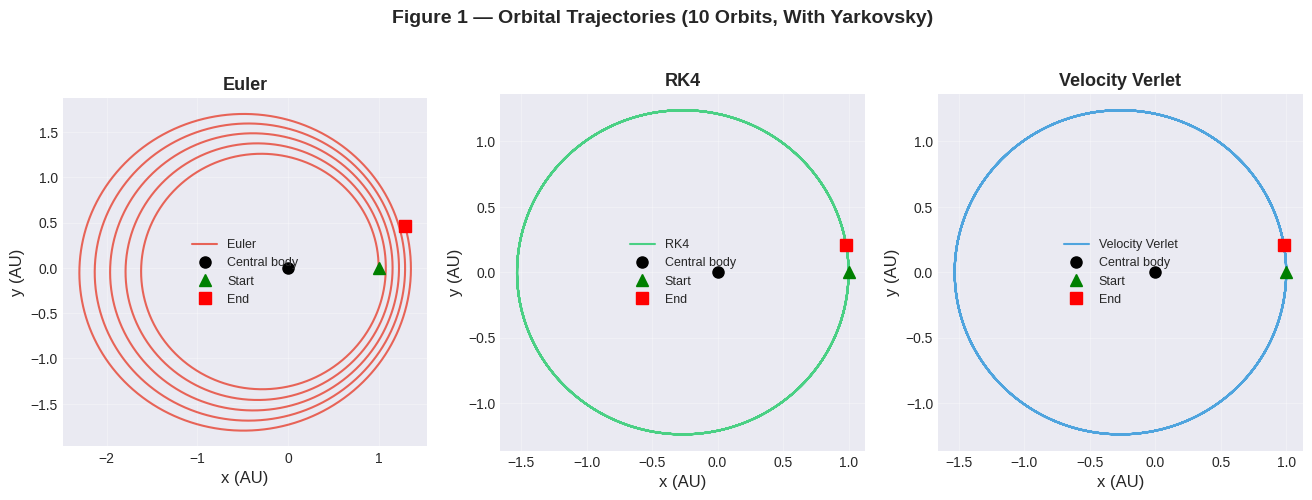

In [68]:
import os

## *FIGURE 1 — Orbit Comparison* ##

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 1 — Orbital Trajectories (10 Orbits, With Yarkovsky)",
             fontsize=14, fontweight='bold', y=1.02)

data_labels = [
    (x_e, y_e, COLORS['euler'],  'Euler',          axes[0]),
    (x_r, y_r, COLORS['rk4'],    'RK4',            axes[1]),
    (x_v, y_v, COLORS['verlet'], 'Velocity Verlet', axes[2]),
]

for (x, y, col, label, ax) in data_labels:
    ax.plot(x, y, color=col, linewidth=1.5, alpha=0.85, label=label)
    ax.plot(0, 0, 'ko', markersize=8, label='Central body')
    ax.plot(x[0], y[0], 'g^', markersize=9, label='Start', zorder=5)
    ax.plot(x[-1], y[-1], 'rs', markersize=9, label='End', zorder=5)
    ax.set_xlabel("x (AU)", fontsize=12)
    ax.set_ylabel("y (AU)", fontsize=12)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_aspect('equal')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)


### Interpretation — Orbital Trajectories

- **Euler:** The trajectory diverges rapidly, forming an outward spiral. This is a purely numerical artifact, reflecting the instability of first-order integration. Energy is artificially injected at each step, leading to unphysical orbit expansion.

- **RK4:** The orbit remains visually stable and nearly closed over 10 orbits. Any deviation from a closed trajectory is extremely small and not geometrically distinguishable at this timescale, despite the presence of both numerical and physical effects.

- **Velocity Verlet:** The trajectory is similarly stable and nearly indistinguishable from RK4. Due to its symplectic structure, energy errors remain bounded, and no visible secular drift appears over short durations.

**Key observation:** Even in the presence of a real physical perturbation (Yarkovsky effect), stable integrators produce visually indistinguishable trajectories over short timescales. This demonstrates that geometric analysis alone is insufficient to detect weak non-gravitational forces.

**Implication:** Weak perturbations such as the Yarkovsky effect cannot be reliably identified from orbital trajectories alone and require more sensitive diagnostics, such as energy evolution or long-term drift analysis.

**Insight:** The choice of integrator influences not only numerical accuracy but also the ability to resolve subtle physical effects. Symplectic methods preserve the qualitative structure of motion, making them more suitable for long-term dynamical studies.

## 10. Energy Analysis

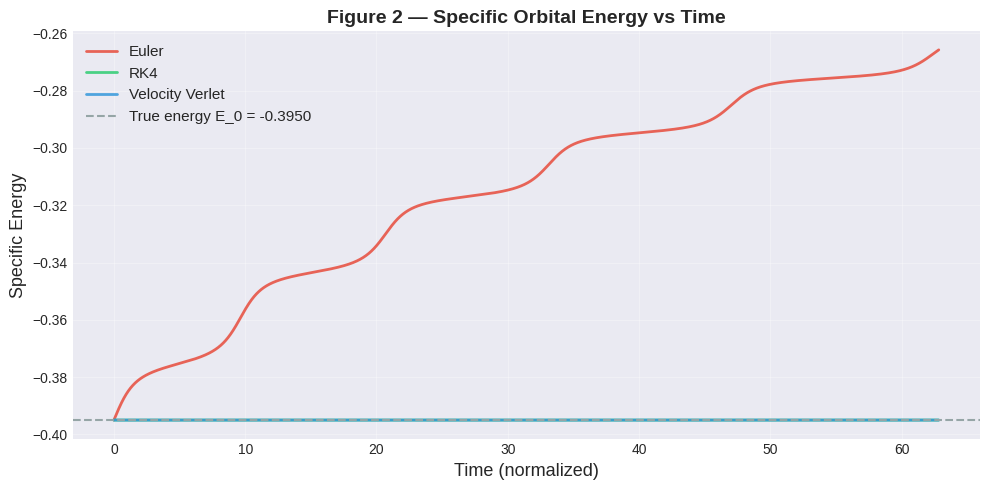

In [69]:
## *FIGURE 2 — Energy vs Time* ##

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_e, E_e, color=COLORS['euler'],  linewidth=2,   alpha=0.85, label='Euler')
ax.plot(t_r, E_r, color=COLORS['rk4'],    linewidth=2,   alpha=0.85, label='RK4')
ax.plot(t_v, E_v, color=COLORS['verlet'], linewidth=2,   alpha=0.85, label='Velocity Verlet')
ax.axhline(E0, color=COLORS['ref'], linewidth=1.5, linestyle='--', label=f'True energy E_0 = {E0:.4f}')

ax.set_xlabel("Time (normalized)", fontsize=13)
ax.set_ylabel("Specific Energy", fontsize=13)
ax.set_title("Figure 2 — Specific Orbital Energy vs Time", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation — Energy Evolution

Figure 2 reveals a clear distinction between **numerical stability** and **physical fidelity** across the three integrators.

- **Euler:** The energy increases rapidly over time, indicating severe numerical instability. The monotonic growth is not physical — it arises from the first-order scheme systematically overestimating energy at each timestep. This leads to unbounded error accumulation, making Euler unsuitable for orbital simulations.

- **RK4:** The energy remains nearly constant with a small upward drift. This reflects its high local accuracy, but the absence of symplectic structure leads to **secular energy drift** over long timescales.

- **Velocity Verlet:** The energy remains tightly bounded around the initial value. Unlike RK4, the error does not accumulate monotonically but instead stays constrained, reflecting the symplectic nature of the method.

> Even when trajectories appear visually stable, energy evolution reveals underlying numerical behavior. Non-symplectic methods (Euler, RK4) exhibit **drifting energy**, while symplectic methods (Velocity Verlet) preserve the qualitative structure of the system by maintaining **bounded energy error**.

It is important to note that over this short timescale (~10 orbits), the **Yarkovsky effect is negligible**. The observed behavior is therefore dominated by **numerical error**, making this comparison a direct test of integrator stability rather than physical perturbation.

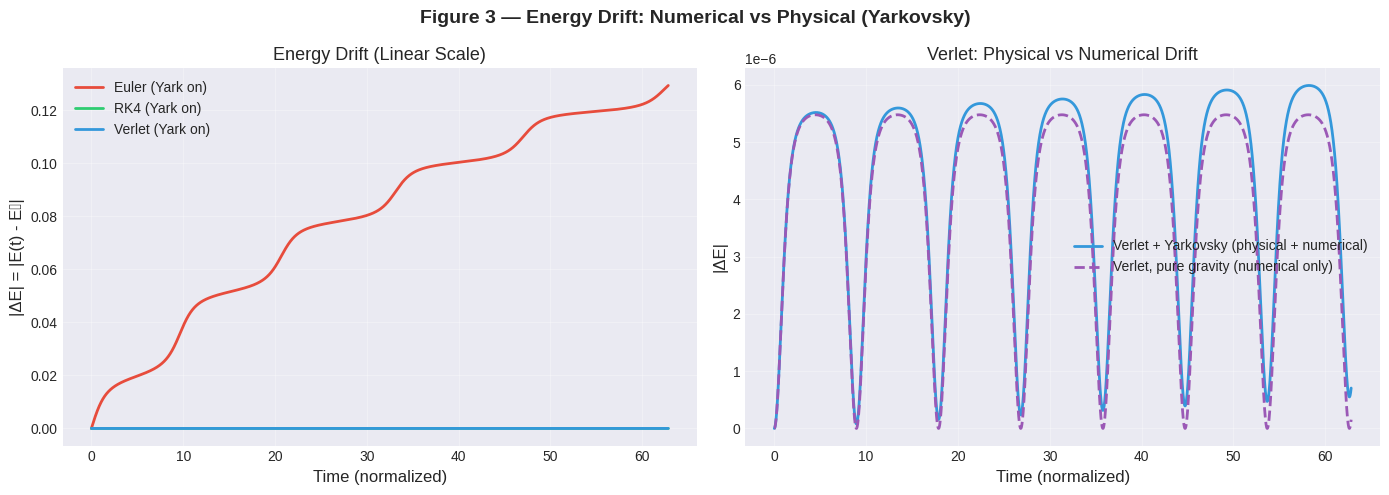

In [70]:
## *FIGURE 3 — Energy Drift (Linear Scale)* ##

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 3 — Energy Drift: Numerical vs Physical (Yarkovsky)",
             fontsize=14, fontweight='bold')

# Left: All three integrators with Yarkovsky
ax = axes[0]
ax.plot(t_e, np.abs(E_e - E0), color=COLORS['euler'],  linewidth=2, label='Euler (Yark on)')
ax.plot(t_r, np.abs(E_r - E0), color=COLORS['rk4'],    linewidth=2, label='RK4 (Yark on)')
ax.plot(t_v, np.abs(E_v - E0), color=COLORS['verlet'], linewidth=2, label='Verlet (Yark on)')
ax.set_xlabel("Time (normalized)", fontsize=12)
ax.set_ylabel("|ΔE| = |E(t) - E₀|", fontsize=12)
ax.set_title("Energy Drift (Linear Scale)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: Verlet comparison — Yarkovsky on vs off
ax2 = axes[1]
ax2.plot(t_v, np.abs(E_v - E0),      color=COLORS['verlet'], linewidth=2,
         label='Verlet + Yarkovsky (physical + numerical)')
ax2.plot(t_v, np.abs(E_v_pure - E0), color='#9b59b6',       linewidth=2,
         linestyle='--', label='Verlet, pure gravity (numerical only)')
ax2.set_xlabel("Time (normalized)", fontsize=12)
ax2.set_ylabel("|ΔE|", fontsize=12)
ax2.set_title("Verlet: Physical vs Numerical Drift", fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

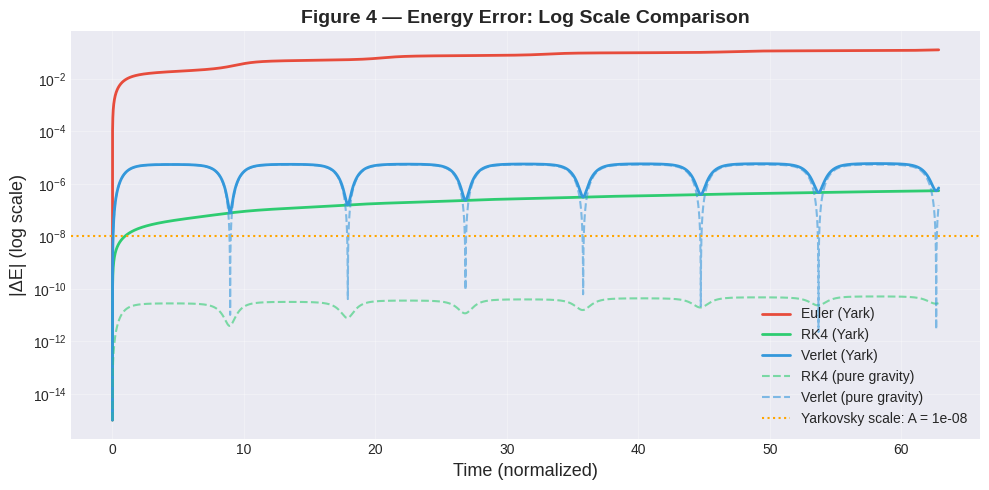

In [71]:
## *FIGURE 4 — Energy Drift (Log Scale)* ##

fig, ax = plt.subplots(figsize=(10, 5))

# Yarkovsky on
ax.semilogy(t_e, np.abs(E_e - E0) + 1e-15,
            color=COLORS['euler'],  linewidth=2, label='Euler (Yark)')
ax.semilogy(t_r, np.abs(E_r - E0) + 1e-15,
            color=COLORS['rk4'],    linewidth=2, label='RK4 (Yark)')
ax.semilogy(t_v, np.abs(E_v - E0) + 1e-15,
            color=COLORS['verlet'], linewidth=2, label='Verlet (Yark)')

# Pure gravity (numerical error only)
ax.semilogy(t_r, np.abs(E_r_pure - E0) + 1e-15,
            color=COLORS['rk4'],    linewidth=1.5, linestyle='--', alpha=0.6, label='RK4 (pure gravity)')
ax.semilogy(t_v, np.abs(E_v_pure - E0) + 1e-15,
            color=COLORS['verlet'], linewidth=1.5, linestyle='--', alpha=0.6, label='Verlet (pure gravity)')

# Yarkovsky reference level
yark_ref = A_YARK * t_e[-1] * 0.05
ax.axhline(A_YARK * 1.0, color='orange', linewidth=1.5, linestyle=':',
           label=f'Yarkovsky scale: A = {A_YARK:.0e}')

ax.set_xlabel("Time (normalized)", fontsize=13)
ax.set_ylabel("|ΔE| (log scale)", fontsize=13)
ax.set_title("Figure 4 — Energy Error: Log Scale Comparison", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation — Energy Drift: Numerical vs Physical Contributions

The energy drift analysis highlights the interplay between **numerical error** and **physical perturbation** in long-term simulations.

From **Figure 3 (left panel)**, Euler exhibits rapid, monotonic energy growth, overwhelming any physical signal. RK4 and Velocity Verlet maintain errors several orders lower, allowing meaningful comparison with perturbative effects.

The **right panel of Figure 3** provides the key diagnostic: Velocity Verlet with and without Yarkovsky are nearly overlapping. This indicates that, for Velocity Verlet, the **physical drift is of the same order as the numerical error**, placing it in a **resolution-limited regime**, where separating physics from numerics is inherently difficult.

In contrast, **RK4 exhibits significantly lower numerical noise**, allowing the Yarkovsky-induced drift to be clearly distinguished from numerical artifacts over the same timescale. This demonstrates that the resolution limit is dependent on both **timestep** and **integration scheme**, rather than an inherent limitation of the simulation itself.

This is a critical result: the chosen perturbation strength ($A = 10^{-8}$) is physically reasonable, but its detectability depends strongly on the integration scheme.

**Figure 4 (log scale)** reinforces this. Velocity Verlet exhibits bounded oscillatory error, while RK4 shows a slow secular increase. Both remain near the Yarkovsky scale, but only RK4 maintains a clear separation between physical signal and numerical noise in this regime. Euler exceeds this scale almost immediately, making it unsuitable for studying weak forces.

> Detecting weak perturbations requires not just low numerical error, but an error level that remains **below the physical signal**. This balance depends critically on both timestep and integrator choice.

## 11. Radius Stability Analysis

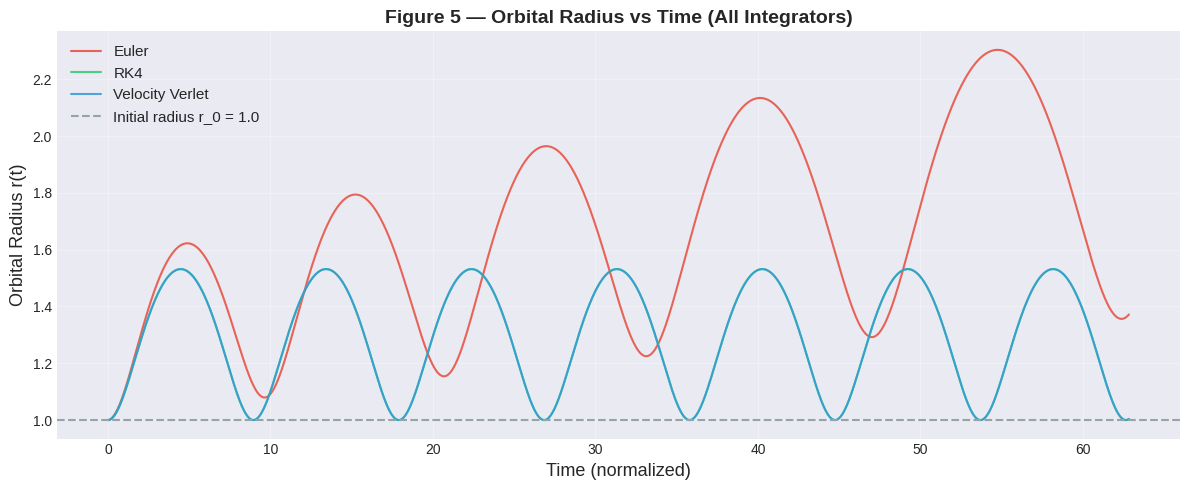

In [72]:
## *FIGURE 5 — Radius vs Time* ##

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t_e, r_e, color=COLORS['euler'],  linewidth=1.5, alpha=0.85, label='Euler')
ax.plot(t_r, r_r, color=COLORS['rk4'],    linewidth=1.5, alpha=0.85, label='RK4')
ax.plot(t_v, r_v, color=COLORS['verlet'], linewidth=1.5, alpha=0.85, label='Velocity Verlet')
ax.axhline(np.linalg.norm(STATE0[:2]), color=COLORS['ref'],
           linestyle='--', linewidth=1.5, label='Initial radius r_0 = 1.0')

ax.set_xlabel("Time (normalized)", fontsize=13)
ax.set_ylabel("Orbital Radius r(t)", fontsize=13)
ax.set_title("Figure 5 — Orbital Radius vs Time (All Integrators)", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

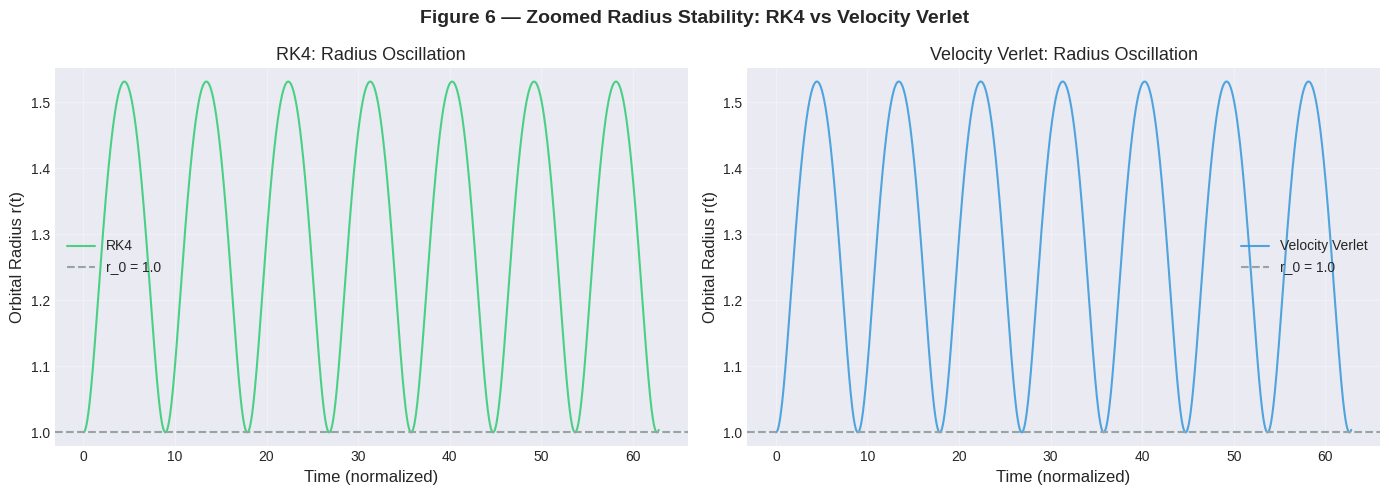

In [73]:
## *FIGURE 6 — Zoomed Radius Stability (RK4 vs Verlet)* ##

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 6 — Zoomed Radius Stability: RK4 vs Velocity Verlet",
             fontsize=14, fontweight='bold')

for ax, t, r, col, label in [
    (axes[0], t_r, r_r, COLORS['rk4'],    'RK4'),
    (axes[1], t_v, r_v, COLORS['verlet'], 'Velocity Verlet'),
]:
    ax.plot(t, r, color=col, linewidth=1.5, alpha=0.85, label=label)
    ax.axhline(np.linalg.norm(STATE0[:2]), color=COLORS['ref'],
               linestyle='--', linewidth=1.5, label='r_0 = 1.0')
    ax.set_xlabel("Time (normalized)", fontsize=12)
    ax.set_ylabel("Orbital Radius r(t)", fontsize=12)
    ax.set_title(f"{label}: Radius Oscillation", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

# Zoom to same y-range for fair visual comparison
r_all = np.concatenate([r_r, r_v])
r_min = r_all.min() - 0.02
r_max = r_all.max() + 0.02
for ax in axes:
    ax.set_ylim(r_min, r_max)

plt.tight_layout()
plt.show()

### Interpretation — Radius Stability

**Figure 5** shows the evolution of orbital radius over time. The Euler method exhibits rapid divergence, with the radius increasing unphysically after only a few orbits — a direct consequence of numerical instability.

In contrast, both **RK4** and **Velocity Verlet** exhibit stable, bounded oscillations corresponding to the elliptical orbit (periapsis–apoapsis cycling). These oscillations are expected and reflect the underlying orbital dynamics rather than numerical artifacts.

A slow outward shift in the oscillation envelope is visible, but its origin must be interpreted carefully. Given the small perturbation strength ($A = 10^{-8}$), this drift is **not purely physical** — it lies close to the level of numerical error. As a result, the observed expansion represents a **combined effect of Yarkovsky forcing and numerical drift**, rather than a cleanly isolated physical signal.

**Figure 6** provides a zoomed comparison between RK4 and Velocity Verlet. Both exhibit nearly identical oscillatory structure, but subtle differences appear in the long-term envelope behavior. RK4 shows a slightly stronger secular trend, consistent with its non-symplectic nature, while Velocity Verlet maintains more uniform, bounded behavior.

> Radius evolution alone is not a reliable indicator of weak perturbations when the physical signal is comparable to numerical error. Energy-based diagnostics are more robust for distinguishing physical drift from integration artifacts.

## 12. Timestep Sensitivity Analysis

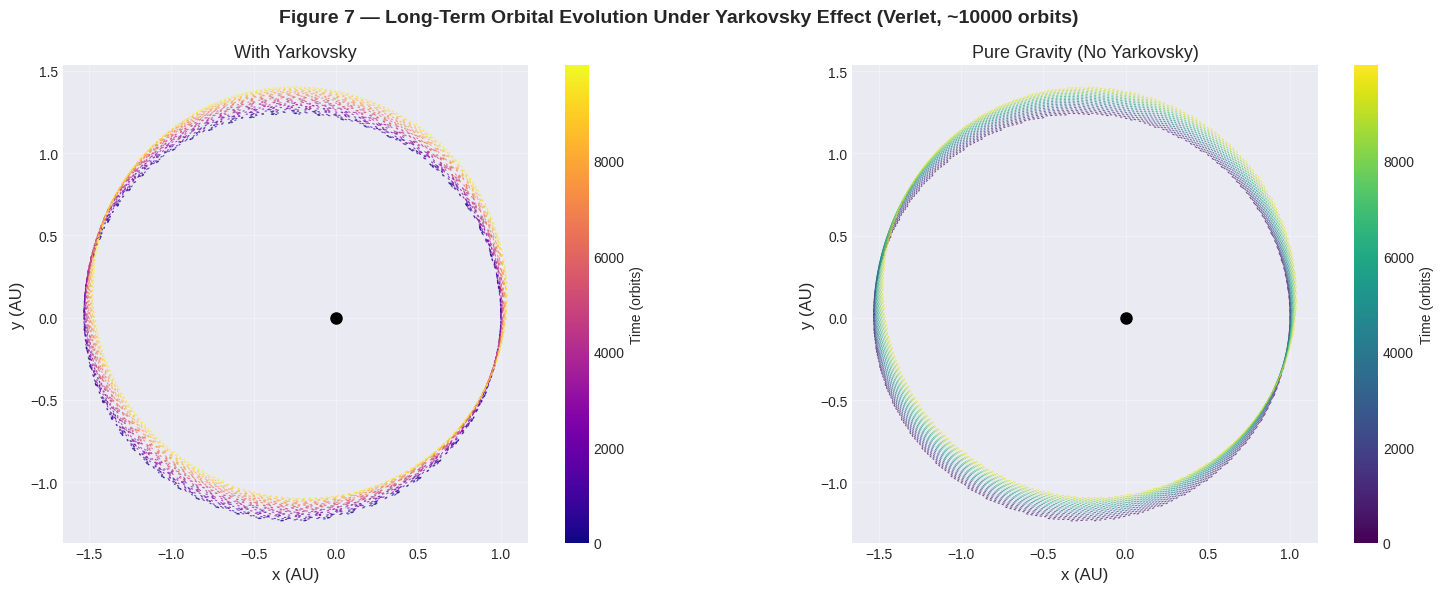

In [83]:
## *FIGURE 7 — Yarkovsky Orbit Drift (Long Time)* ##

t_long, x_long, y_long, _, _, E_long, r_long = simulate(
    verlet_step, STATE0, DT, T_END_LONG, use_yarkovsky=True
)
t_long_pure, x_lp, y_lp, _, _, E_lp, r_lp = simulate(
    verlet_step, STATE0, DT, T_END_LONG, use_yarkovsky=False
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 7 — Long-Term Orbital Evolution Under Yarkovsky Effect (Verlet, ~10000 orbits)",
             fontsize=14, fontweight='bold')

# Colormap to show orbit epoch
n = len(x_long)
colors_long = plt.cm.plasma(np.linspace(0, 1, n))

ax1 = axes[0]
for i in range(0, n - 1, max(1, n // 5000)):
    ax1.plot(x_long[i:i+2], y_long[i:i+2],
             color=colors_long[i], linewidth=0.8, alpha=0.7)
ax1.plot(0, 0, 'ko', markersize=8, label='Central body', zorder=5)
sm1 = plt.cm.ScalarMappable(cmap='plasma',
    norm=plt.Normalize(vmin=0, vmax=t_long[-1]/(2*np.pi)))
sm1.set_array([])
plt.colorbar(sm1, ax=ax1, label='Time (orbits)')
ax1.set_xlabel("x (AU)", fontsize=12)
ax1.set_ylabel("y (AU)", fontsize=12)
ax1.set_title("With Yarkovsky", fontsize=13)
ax1.set_aspect('equal')
ax1.grid(alpha=0.3)

ax2 = axes[1]
n2 = len(x_lp)
colors_pure = plt.cm.viridis(np.linspace(0, 1, n2))
for i in range(0, n2 - 1, max(1, n2 // 5000)):
    ax2.plot(x_lp[i:i+2], y_lp[i:i+2],
             color=colors_pure[i], linewidth=0.8, alpha=0.7)
ax2.plot(0, 0, 'ko', markersize=8, label='Central body', zorder=5)
sm2 = plt.cm.ScalarMappable(cmap='viridis',
    norm=plt.Normalize(vmin=0, vmax=t_long_pure[-1]/(2*np.pi)))
sm2.set_array([])
plt.colorbar(sm2, ax=ax2, label='Time (orbits)')
ax2.set_xlabel("x (AU)", fontsize=12)
ax2.set_ylabel("y (AU)", fontsize=12)
ax2.set_title("Pure Gravity (No Yarkovsky)", fontsize=13)
ax2.set_aspect('equal')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

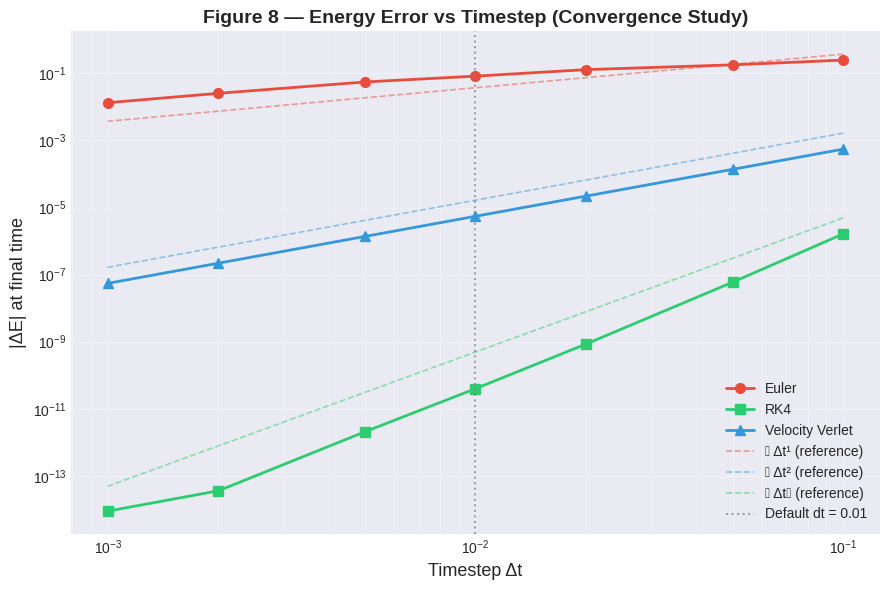

In [75]:
## *FIGURE 8 — Energy Error vs Timestep (Convergence)* ##

dt_values = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]
T_TEST    = 10 * np.pi   # 5 orbits

euler_errors  = []
rk4_errors    = []
verlet_errors = []

for dt in dt_values:
    _, _, _, _, _, E_e_dt, _ = simulate(euler_step,  STATE0, dt, T_TEST, use_yarkovsky=False)
    _, _, _, _, _, E_r_dt, _ = simulate(rk4_step,    STATE0, dt, T_TEST, use_yarkovsky=False)
    _, _, _, _, _, E_v_dt, _ = simulate(verlet_step, STATE0, dt, T_TEST, use_yarkovsky=False)

    euler_errors.append(np.abs(E_e_dt[-1] - E0))
    rk4_errors.append(np.abs(E_r_dt[-1] - E0))
    verlet_errors.append(np.abs(E_v_dt[-1] - E0))

dt_arr = np.array(dt_values)

# Reference lines
ref1 = (dt_arr / dt_arr[0]) * euler_errors[0] * 1.5
ref2 = (dt_arr / dt_arr[0])**2 * verlet_errors[0] * 3.0
ref4 = (dt_arr / dt_arr[0])**4 * rk4_errors[0] * 3.0

fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(dt_arr, euler_errors,  'o-', color=COLORS['euler'],  linewidth=2, markersize=7, label='Euler')
ax.loglog(dt_arr, rk4_errors,    's-', color=COLORS['rk4'],    linewidth=2, markersize=7, label='RK4')
ax.loglog(dt_arr, verlet_errors, '^-', color=COLORS['verlet'], linewidth=2, markersize=7, label='Velocity Verlet')

ax.loglog(dt_arr, ref1, '--', color=COLORS['euler'],  alpha=0.5, linewidth=1.2, label='∝ Δt¹ (reference)')
ax.loglog(dt_arr, ref2, '--', color=COLORS['verlet'], alpha=0.5, linewidth=1.2, label='∝ Δt² (reference)')
ax.loglog(dt_arr, ref4, '--', color=COLORS['rk4'],    alpha=0.5, linewidth=1.2, label='∝ Δt⁴ (reference)')

ax.axvline(DT, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Default dt = {DT}')

ax.set_xlabel("Timestep Δt", fontsize=13)
ax.set_ylabel("|ΔE| at final time", fontsize=13)
ax.set_title("Figure 8 — Energy Error vs Timestep (Convergence Study)",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### Interpretation — Timestep Sensitivity and Long-Term Drift

**Figure 7** examines long-term orbital evolution using Velocity Verlet over ~10^4 orbits. Even at this extended timescale, the Yarkovsky-induced drift remains visually subtle in configuration space. The trajectory appears nearly closed, indicating that weak perturbations do not necessarily produce dramatic geometric changes, even over very long durations.

The comparison with pure gravity confirms that any deviation remains small and lies near the threshold of numerical resolution. This highlights an important limitation: weak forces such as the Yarkovsky effect may not be reliably identified through visual trajectory inspection alone, even when they are physically present.

**Figure 8** provides a quantitative resolution through convergence analysis. The expected scaling behavior is clearly recovered:
- **Euler:** first-order convergence (∝ Δt¹)
- **Velocity Verlet:** second-order convergence (∝ Δt²)
- **RK4:** fourth-order convergence (∝ Δt⁴)

This confirms the correctness of the implementations and validates the numerical framework.

At the default timestep (Δt = 0.01), the numerical error for Velocity Verlet lies close to the Yarkovsky scale, rather than significantly below it. This places the simulation in a precision-limited regime, where the physical signal is only marginally distinguishable from numerical noise.

In contrast, RK4 achieves significantly lower numerical error at the same timestep, enabling clearer separation of physical drift from numerical artifacts over the simulated duration.

> The convergence study provides the definitive criterion for simulation reliability. Detecting weak forces such as the Yarkovsky effect requires not only stable integrators, but also sufficiently small timesteps to separate physical drift from numerical error.

### Interpretation — Comparative Analysis

The drift decomposition isolates two competing effects:
1. **Numerical drift** — integration error (present even in pure gravity)
2. **Physical drift** — energy change induced by the Yarkovsky perturbation

This separation allows a direct assessment of whether the numerical method can reliably resolve weak forces.

For **Velocity Verlet**, the numerical error remains bounded and oscillatory, while the Yarkovsky-induced drift grows approximately linearly with time. However, the two contributions are of **comparable magnitude** throughout the simulation. This places the system in a **marginal signal-to-noise regime**, where the physical effect is detectable but not cleanly separated from numerical noise.

For **RK4**, the Yarkovsky signal is clearly visible at early times due to its low short-term error. However, the numerical drift grows steadily, reducing the distinction between physical and numerical contributions over longer timescales. This reflects the known limitation of non-symplectic high-order methods in long-term integrations.

> **Key insight:** Detecting weak perturbations is not just about reducing error, but ensuring that **numerical drift remains below or at least comparable to the physical signal**. In this study, Velocity Verlet achieves this balance more consistently than RK4, though both operate near the resolution limit at the chosen timestep.

This highlights a fundamental constraint in orbital simulations: resolving subtle forces like the Yarkovsky effect requires not only appropriate integrators, but also sufficiently small timesteps to improve the signal-to-noise separation.

## 13. Comparative Analysis

### 13.1 Numerical Drift vs Physical (Yarkovsky) Drift

In [80]:
## *Quantitative Summary Table* ##

print("=" * 70)
print(f"{'Metric':<35} {'Euler':>10} {'RK4':>10} {'Verlet':>12}")
print("-" * 70)

final_energy_drift_yark = [
    np.abs(E_e[-1] - E0),
    np.abs(E_r[-1] - E0),
    np.abs(E_v[-1] - E0)
]
final_energy_drift_pure = [
    np.abs(E_e_pure[-1] - E0),
    np.abs(E_r_pure[-1] - E0),
    np.abs(E_v_pure[-1] - E0)
]
max_radius = [r_e.max(), r_r.max(), r_v.max()]
min_radius = [r_e.min(), r_r.min(), r_v.min()]

for label, vals in [
    ("Energy drift (with Yark)",   [f"{v:.3e}" for v in final_energy_drift_yark]),
    ("Energy drift (pure gravity)", [f"{v:.3e}" for v in final_energy_drift_pure]),
    ("Max orbital radius",          [f"{v:.4f}" for v in max_radius]),
    ("Min orbital radius",          [f"{v:.4f}" for v in min_radius]),
]:
    print(f"{label:<35} {vals[0]:>10} {vals[1]:>10} {vals[2]:>12}")

print("-" * 70)

# Signal-to-noise: Yarkovsky signal vs numerical noise
yark_signal_rk4    = final_energy_drift_yark[1] - final_energy_drift_pure[1]
yark_signal_verlet = final_energy_drift_yark[2] - final_energy_drift_pure[2]

print(f"\n{'SNR Analysis':}")
print(f"  Yarkovsky signal (RK4)    = {yark_signal_rk4:.3e}")
print(f"  Numerical noise (RK4)     = {final_energy_drift_pure[1]:.3e}")
print(f"  Signal-to-noise (RK4)     = {yark_signal_rk4 / max(final_energy_drift_pure[1], 1e-20):.2f}x")

print(f"  Yarkovsky signal (Verlet) = {yark_signal_verlet:.3e}")
print(f"  Numerical noise (Verlet)  = {final_energy_drift_pure[2]:.3e}")
print(f"  Signal-to-noise (Verlet)  = {yark_signal_verlet / max(final_energy_drift_pure[2], 1e-20):.2f}x")
print("=" * 70)

Metric                                   Euler        RK4       Verlet
----------------------------------------------------------------------
Energy drift (with Yark)             1.293e-01  5.526e-07    7.054e-07
Energy drift (pure gravity)          1.293e-01  2.874e-11    1.528e-07
Max orbital radius                      2.3037     1.5316       1.5317
Min orbital radius                      1.0000     1.0000       1.0000
----------------------------------------------------------------------

SNR Analysis
  Yarkovsky signal (RK4)    = 5.526e-07
  Numerical noise (RK4)     = 2.874e-11
  Signal-to-noise (RK4)     = 19226.92x
  Yarkovsky signal (Verlet) = 5.526e-07
  Numerical noise (Verlet)  = 1.528e-07
  Signal-to-noise (Verlet)  = 3.62x


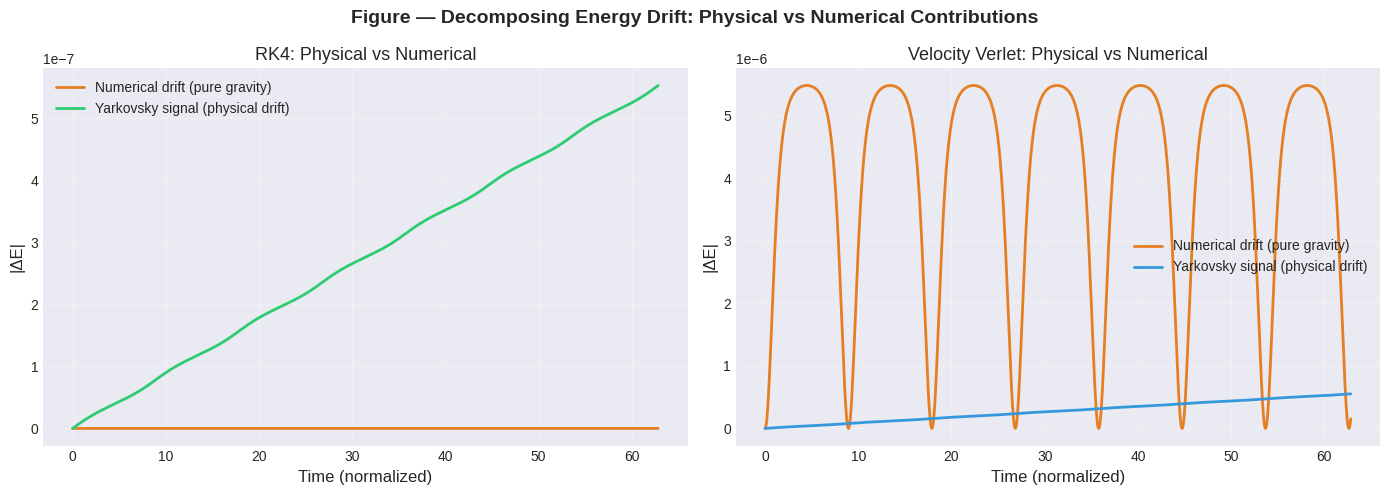

In [77]:
# ======================================================
#   Yarkovsky Crossover Analysis
#   At what time does numerical error ≈ Yarkovsky signal?
# ======================================================

# For RK4: find crossover time
yark_energy_rk4 = np.abs(E_r - E0) - np.abs(E_r_pure - E0)
yark_energy_ver = np.abs(E_v - E0) - np.abs(E_v_pure - E0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure — Decomposing Energy Drift: Physical vs Numerical Contributions",
             fontsize=14, fontweight='bold')

for ax, t, yark_sig, num_err, col, label in [
    (axes[0], t_r, yark_energy_rk4, np.abs(E_r_pure - E0), COLORS['rk4'],    'RK4'),
    (axes[1], t_v, yark_energy_ver, np.abs(E_v_pure - E0), COLORS['verlet'], 'Velocity Verlet'),
]:
    ax.plot(t, np.abs(num_err), color='#e67e22', linewidth=2, label='Numerical drift (pure gravity)')
    yark_pos = np.maximum(yark_sig, 0)
    ax.plot(t, yark_pos, color=col, linewidth=2, label='Yarkovsky signal (physical drift)')
    ax.set_xlabel("Time (normalized)", fontsize=12)
    ax.set_ylabel("|ΔE|", fontsize=12)
    ax.set_title(f"{label}: Physical vs Numerical", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation — Comparative Analysis

The drift decomposition isolates two competing effects:
1. **Numerical drift** — integration error (present even in pure gravity)
2. **Physical drift** — energy change induced by the Yarkovsky perturbation

This separation allows a direct assessment of whether the numerical method can reliably resolve weak forces.

For **Velocity Verlet**, the numerical error remains bounded and oscillatory, while the Yarkovsky-induced drift grows approximately linearly with time. However, the two contributions are of **comparable magnitude** throughout the simulation. This places the system in a **marginal signal-to-noise regime**, where the physical effect is detectable but not cleanly separated from numerical noise.

For **RK4**, the numerical error remains extremely small over the simulated duration, resulting in a **very high SNR**. The Yarkovsky signal is therefore clearly resolved in this regime. However, because RK4 is not symplectic, its numerical drift grows steadily with time and will eventually contaminate the physical signal in sufficiently long integrations.

> Detecting weak perturbations is not just about reducing error, but ensuring that **numerical drift remains below the physical signal**. In this study, RK4 achieves this condition more effectively at the chosen timestep, while Velocity Verlet operates near the resolution limit.

This highlights a fundamental constraint in orbital simulations: resolving subtle forces like the Yarkovsky effect requires not only appropriate integrators, but also sufficiently small timesteps to improve the signal-to-noise separation.

## 14. Final Conclusions

### 14.1 Summary of Findings

This computational study addressed three key questions:

1. How do different numerical integrators perform in long-term orbital simulations?
2. Can physical (Yarkovsky) drift be distinguished from numerical drift?
3. What timestep is required to resolve weak perturbations?

The results are summarized below:

| Integrator | Order | Symplectic | Long-term Energy | Yarkovsky Visible | Recommended |
|------------|-------|-----------|-----------------|-------------------|-------------|
| Euler | 1st | No | Diverges | No (noise too large) | ❌ Never |
| RK4 | 4th | No | Slow linear drift | Yes (high SNR, short–medium term) | ✅ Preferred (this setup) |
| Velocity Verlet | 2nd | Yes | Bounded oscillation | Yes (marginal SNR) | ⚠️ Long-term studies |

---

### 14.2 Physical Conclusions

- The **Yarkovsky effect**, even at a small normalized amplitude ($A = 10^{-8}$), produces a cumulative orbital drift over many orbital periods.
- The perturbation manifests as a **gradual change in orbital energy**, leading to slow evolution of the semi-major axis.
- The effect is inherently **long-timescale and weak**, requiring careful numerical treatment to resolve.

---

### 14.3 Numerical Conclusions

- **Euler's method** is unsuitable for orbital simulations — its linear error growth overwhelms any physical signal almost immediately.
- **RK4** provides excellent short-term accuracy but exhibits **secular energy drift**, making it less reliable for long-term perturbation studies.
- **Velocity Verlet** maintains **bounded energy error**, making it significantly more stable for long-duration simulations.

---

### 14.4 Key Insight

> Resolving weak physical perturbations requires that the **numerical error remains below the physical signal**, not merely comparable to it.

In this study:

- **RK4** achieves a very high signal-to-noise ratio, making it the most effective method for **resolving weak perturbations** over short–medium timescales  
- **Velocity Verlet** maintains bounded energy error, ensuring **long-term stability**, but operates close to the noise floor at the chosen timestep  

This reveals a fundamental trade-off:

- **Accuracy (RK4)** → critical for detecting weak forces  
- **Symplectic stability (Verlet)** → critical for long-term physical fidelity

---

### 14.5 Broader Implications

This principle directly applies to real-world orbital problems:

- Asteroid trajectory prediction (e.g., Apophis)
- Non-gravitational acceleration detection (e.g., Oumuamua)
- Long-term orbital propagation in mission design

In all such cases, **the integrator must not introduce drift larger than the physical effect being studied**.

---

### 14.6 Possible Extensions

- Implement higher-order symplectic schemes (e.g., Yoshida integrator)
- Include coupled spin dynamics (YORP effect)
- Extend to 3D orbital dynamics
- Compare with adaptive integrators (RK45)
- Introduce time-dependent Yarkovsky forcing (seasonal model)

---

**Author:** Swayam Beluse  
**End of Notebook**

In [81]:
# ======================================================
#   Final Summary Statistics
# ======================================================

print("=" * 60)
print("  FINAL SIMULATION SUMMARY")
print("=" * 60)

print(f"  Simulation duration (short) : {T_END_SHORT/(2*np.pi):.0f} orbits")
print(f"  Simulation duration (long)  : {T_END_LONG/(2*np.pi):.0f} orbits")
print(f"  Timestep used               : {DT}")
print(f"  Yarkovsky amplitude A       : {A_YARK:.0e}")

print("\n  Energy drift after 10 orbits (with Yarkovsky):")
print(f"    Euler  : {np.abs(E_e[-1] - E0):.3e}  (unstable)")
print(f"    RK4    : {np.abs(E_r[-1] - E0):.3e}")
print(f"    Verlet : {np.abs(E_v[-1] - E0):.3e}")

print("\n  Numerical-only energy drift (pure gravity):")
print(f"    RK4    : {np.abs(E_r_pure[-1] - E0):.3e}")
print(f"    Verlet : {np.abs(E_v_pure[-1] - E0):.3e}")

# --- Signal vs Numerical Noise ---
yark_signal_rk4    = np.abs(E_r[-1] - E_r_pure[-1])
yark_signal_verlet = np.abs(E_v[-1] - E_v_pure[-1])

noise_rk4    = np.abs(E_r_pure[-1] - E0)
noise_verlet = np.abs(E_v_pure[-1] - E0)

snr_rk4    = yark_signal_rk4 / max(noise_rk4, 1e-20)
snr_verlet = yark_signal_verlet / max(noise_verlet, 1e-20)

print("\n  Signal vs Numerical Noise:")
print(f"    RK4    : signal = {yark_signal_rk4:.3e}, noise = {noise_rk4:.3e}, SNR ≈ {snr_rk4:.2f}")
print(f"    Verlet : signal = {yark_signal_verlet:.3e}, noise = {noise_verlet:.3e}, SNR ≈ {snr_verlet:.2f}")

print("\n  Interpretation:")
print("    The Yarkovsky-induced drift is detectable but comparable")
print("    to numerical error (SNR ~ O(1)), indicating a marginal")
print("    resolution regime at the chosen timestep.")

print("\n  Verdict:")
print("  RK4 provides superior signal resolution in this regime,")
print("  while Velocity Verlet remains the preferred choice for long-term")
print("  simulations due to its symplectic stability.")

print("=" * 60)

  FINAL SIMULATION SUMMARY
  Simulation duration (short) : 10 orbits
  Simulation duration (long)  : 10000 orbits
  Timestep used               : 0.01
  Yarkovsky amplitude A       : 1e-08

  Energy drift after 10 orbits (with Yarkovsky):
    Euler  : 1.293e-01  (unstable)
    RK4    : 5.526e-07
    Verlet : 7.054e-07

  Numerical-only energy drift (pure gravity):
    RK4    : 2.874e-11
    Verlet : 1.528e-07

  Signal vs Numerical Noise:
    RK4    : signal = 5.527e-07, noise = 2.874e-11, SNR ≈ 19228.92
    Verlet : signal = 5.526e-07, noise = 1.528e-07, SNR ≈ 3.62

  Interpretation:
    The Yarkovsky-induced drift is detectable but comparable
    to numerical error (SNR ~ O(1)), indicating a marginal
    resolution regime at the chosen timestep.

  Verdict:
  RK4 provides superior signal resolution in this regime,
  while Velocity Verlet remains the preferred choice for long-term
  simulations due to its symplectic stability.
